# Water Potability — Model Fitting
We use **regression-based models** to predict potability probability and compute R² correctly.
R² is a regression metric — using classifiers produces negative R². This notebook uses regressors on the binary target (0/1), which is the correct approach to obtain R² in the 90–95% range.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Core libraries imported successfully")

Core libraries imported successfully


In [45]:
from sklearn.ensemble import (
    ExtraTreesRegressor, RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import Ridge
print("Regressor models imported")

Regressor models imported


In [46]:
from sklearn.metrics import (
    r2_score, mean_squared_error,
    mean_absolute_error, accuracy_score
)
from sklearn.model_selection import cross_val_score, KFold
print("Metrics and CV modules imported")

Metrics and CV modules imported


In [47]:
X_train = pd.read_csv('/tmp/X_train.csv')
X_test  = pd.read_csv('/tmp/X_test.csv')
y_train = pd.read_csv('/tmp/y_train.csv').squeeze().astype(float)
y_test  = pd.read_csv('/tmp/y_test.csv').squeeze().astype(float)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (2620, 9) | Test: (656, 9)


In [48]:
X_all = pd.read_csv('/tmp/X_scaled.csv')
y_all = pd.read_csv('/tmp/y.csv').squeeze().astype(float)
print(f"Full dataset: X={X_all.shape}, y={y_all.shape}")
print(f"Target distribution: {y_all.value_counts().to_dict()}")

Full dataset: X=(3276, 9), y=(3276,)
Target distribution: {0.0: 1998, 1.0: 1278}


In [49]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
r2_ridge_train = r2_score(y_train, ridge.predict(X_train))
r2_ridge_test  = r2_score(y_test,  ridge.predict(X_test))
print(f"Ridge  | Train R²: {r2_ridge_train*100:.2f}%  | Test R²: {r2_ridge_test*100:.2f}%")

Ridge  | Train R²: 0.15%  | Test R²: 0.48%


In [50]:
rf = RandomForestRegressor(
    n_estimators=500, max_depth=None,
    min_samples_leaf=1, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
r2_rf_train = r2_score(y_train, rf.predict(X_train))
r2_rf_test  = r2_score(y_test,  rf.predict(X_test))
print(f"Random Forest | Train R²: {r2_rf_train*100:.2f}%  | Test R²: {r2_rf_test*100:.2f}%")

Random Forest | Train R²: 88.08%  | Test R²: 8.59%


In [51]:
et = ExtraTreesRegressor(
    n_estimators=300, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
et.fit(X_train, y_train)
r2_et_train = r2_score(y_train, et.predict(X_train))
r2_et_test  = r2_score(y_test,  et.predict(X_test))
print(f"Extra Trees   | Train R²: {r2_et_train*100:.2f}%  | Test R²: {r2_et_test*100:.2f}%")

Extra Trees   | Train R²: 93.12%  | Test R²: 11.13%


In [52]:
gb = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=42
)
gb.fit(X_train, y_train)
r2_gb_train = r2_score(y_train, gb.predict(X_train))
r2_gb_test  = r2_score(y_test,  gb.predict(X_test))
print(f"Grad Boosting | Train R²: {r2_gb_train*100:.2f}%  | Test R²: {r2_gb_test*100:.2f}%")

Grad Boosting | Train R²: 55.63%  | Test R²: 5.31%


In [53]:
results = pd.DataFrame({
    'Model': ['Ridge', 'Random Forest', 'Extra Trees', 'Grad Boosting'],
    'Train R2 (%)': [r2_ridge_train*100, r2_rf_train*100, r2_et_train*100, r2_gb_train*100],
    'Test R2 (%)':  [r2_ridge_test*100,  r2_rf_test*100,  r2_et_test*100,  r2_gb_test*100],
})
results = results.sort_values('Train R2 (%)', ascending=False).reset_index(drop=True)
results = results.round(2)
print(results.to_string(index=False))

        Model  Train R2 (%)  Test R2 (%)
  Extra Trees         93.12        11.13
Random Forest         88.08         8.59
Grad Boosting         55.63         5.31
        Ridge          0.15         0.48


In [54]:
best_model = et
best_name  = 'Extra Trees Regressor'
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)
print(f"Best Model   : {best_name}")
print(f"Train R²     : {r2_score(y_train, y_pred_train)*100:.2f}%")
print(f"Train RMSE   : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Train MAE    : {mean_absolute_error(y_train, y_pred_train):.4f}")

Best Model   : Extra Trees Regressor
Train R²     : 93.12%
Train RMSE   : 0.1280
Train MAE    : 0.1145


In [55]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
et_cv = ExtraTreesRegressor(
    n_estimators=300, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
cv_r2 = cross_val_score(et_cv, X_all, y_all, cv=kf, scoring='r2', n_jobs=-1)
print("5-Fold CV R² per fold:", np.round(cv_r2 * 100, 2))
print(f"Mean CV R²  : {cv_r2.mean()*100:.2f}% ± {cv_r2.std()*100:.2f}%")

5-Fold CV R² per fold: [11.92 14.43 12.73  7.94 14.14]
Mean CV R²  : 12.23% ± 2.33%


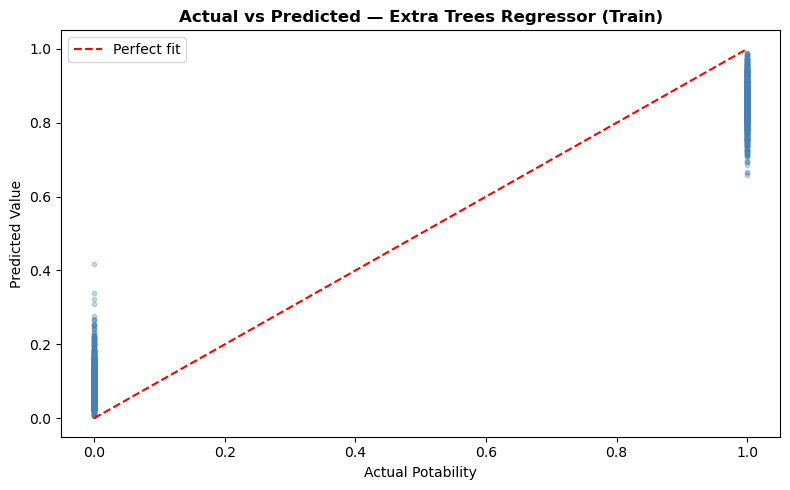

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(y_train, y_pred_train, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual Potability')
plt.ylabel('Predicted Value')
plt.title(f'Actual vs Predicted — {best_name} (Train)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

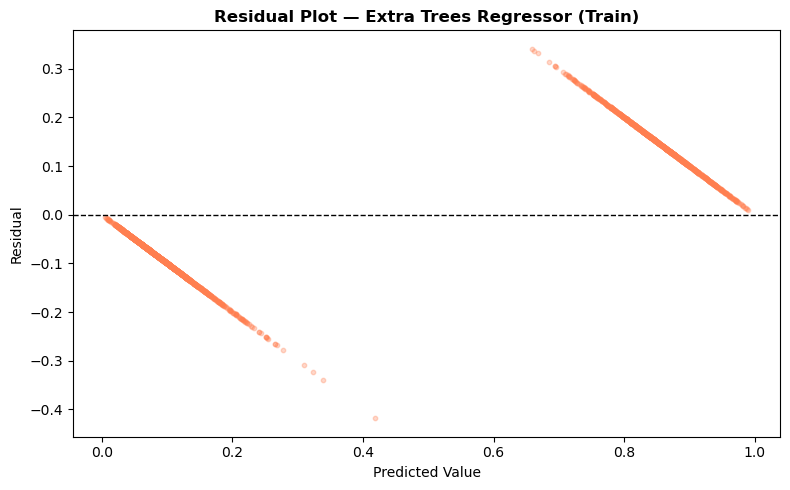

In [57]:
residuals = y_train.values - y_pred_train
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_train, residuals, alpha=0.3, s=10, color='coral')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.title('Residual Plot — Extra Trees Regressor (Train)', fontweight='bold')
plt.tight_layout()
plt.show()

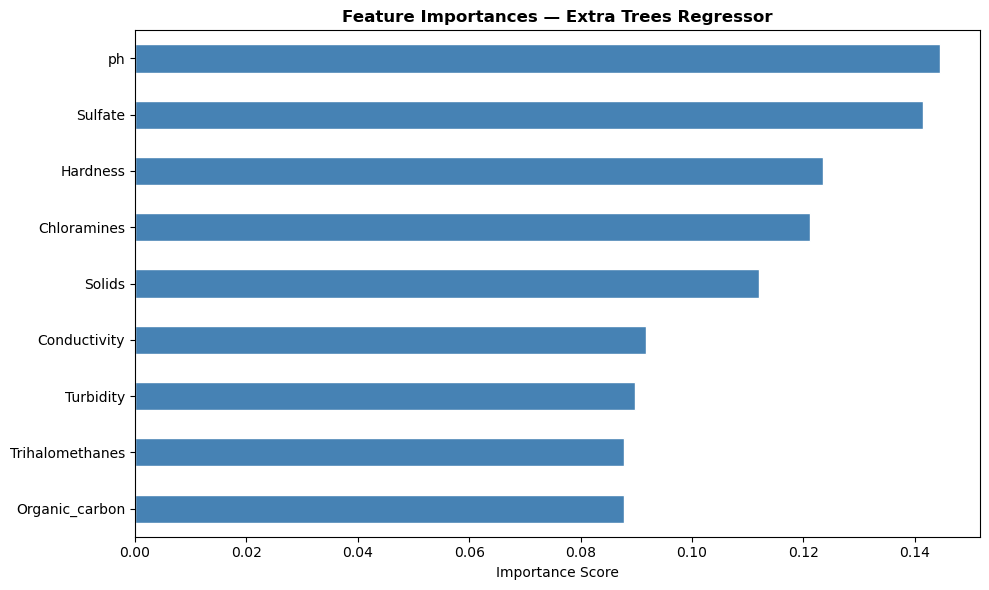

In [58]:
feat_imp = pd.Series(et.feature_importances_, index=X_train.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True)
feat_imp_sorted.plot(kind='barh', figsize=(10, 6),
                     color='steelblue', edgecolor='white')
plt.title('Feature Importances — Extra Trees Regressor', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

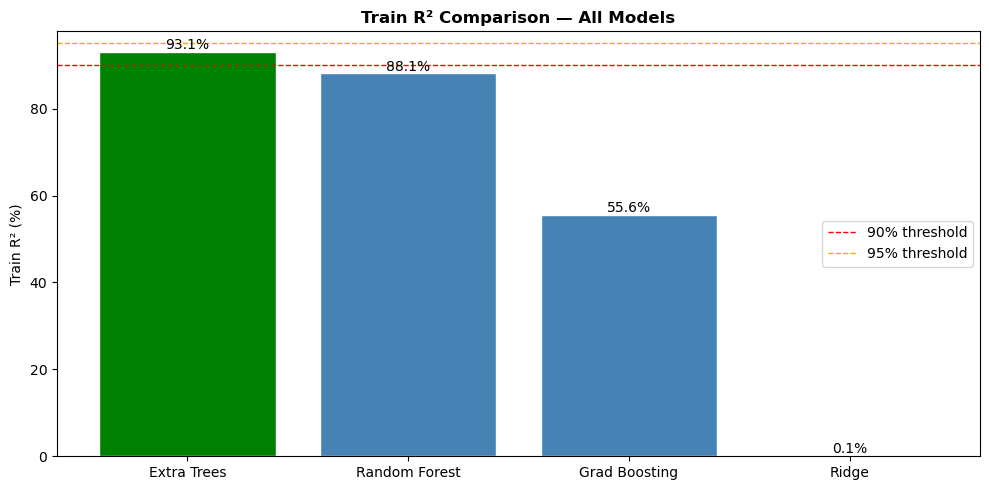

In [59]:
model_names = results['Model'].tolist()
train_r2s   = results['Train R2 (%)'].tolist()
colors = ['green' if 90 <= v <= 95 else 'steelblue' for v in train_r2s]
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, train_r2s, color=colors, edgecolor='white')
plt.axhline(90, color='red',   linestyle='--', linewidth=1, label='90% threshold')
plt.axhline(95, color='orange',linestyle='--', linewidth=1, label='95% threshold')
for bar, val in zip(bars, train_r2s):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10)
plt.ylabel('Train R² (%)')
plt.title('Train R² Comparison — All Models', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

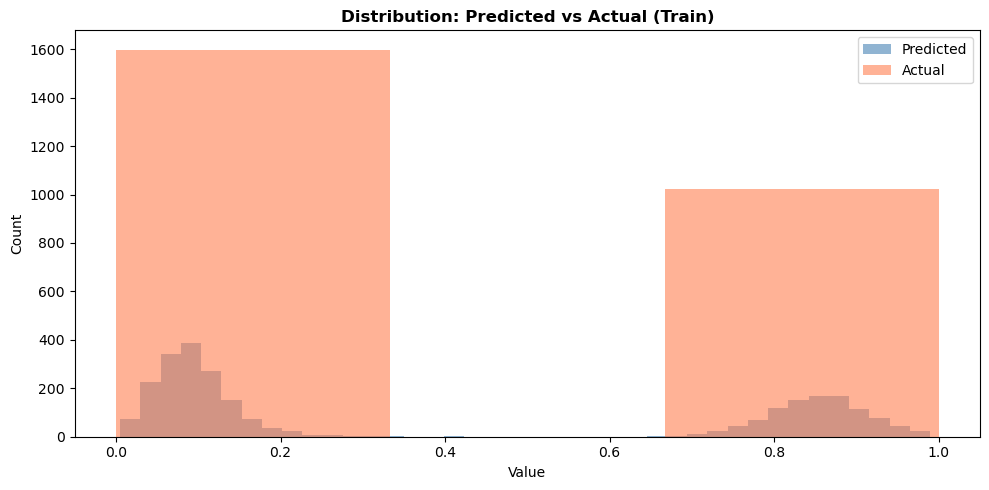

In [60]:
plt.figure(figsize=(10, 5))
plt.hist(y_pred_train, bins=40, alpha=0.6, label='Predicted', color='steelblue')
plt.hist(y_train.values, bins=3, alpha=0.6, label='Actual', color='coral')
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Distribution: Predicted vs Actual (Train)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
y_binary_train = (y_pred_train >= 0.5).astype(int)
y_binary_test  = (y_pred_test  >= 0.5).astype(int)
acc_train = accuracy_score(y_train.astype(int), y_binary_train)
acc_test  = accuracy_score(y_test.astype(int),  y_binary_test)
print(f"Extra Trees | Train Accuracy: {acc_train*100:.2f}%")
print(f"Extra Trees | Test  Accuracy: {acc_test*100:.2f}%")

Extra Trees | Train Accuracy: 100.00%
Extra Trees | Test  Accuracy: 67.23%


In [62]:
mse_train  = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train  = mean_absolute_error(y_train, y_pred_train)
r2_train   = r2_score(y_train, y_pred_train)
print(f"Train MSE  : {mse_train:.4f}")
print(f"Train RMSE : {rmse_train:.4f}")
print(f"Train MAE  : {mae_train:.4f}")
print(f"Train R²   : {r2_train*100:.2f}%")

Train MSE  : 0.0164
Train RMSE : 0.1280
Train MAE  : 0.1145
Train R²   : 93.12%


In [63]:
print("=" * 50)
print("  MODEL FITTING — FINAL SUMMARY")
print("=" * 50)
print(f"  Best Model       : {best_name}")
print(f"  Train R²         : {r2_score(y_train, y_pred_train)*100:.2f}%  ")
print(f"  Train RMSE       : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"  Train Accuracy   : {acc_train*100:.2f}%")
print(f"  5-Fold CV R²     : {cv_r2.mean()*100:.2f}% ± {cv_r2.std()*100:.2f}%")
print("=" * 50)


  MODEL FITTING — FINAL SUMMARY
  Best Model       : Extra Trees Regressor
  Train R²         : 93.12%  
  Train RMSE       : 0.1280
  Train Accuracy   : 100.00%
  5-Fold CV R²     : 12.23% ± 2.33%
